Imports and Initialization

In [1]:
import os
os.environ['PYTHONHASHSEED'] = '0'

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report,confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

import random

random.seed(0)
np.random.seed(0)

In [4]:
import re                                  # library for regular expression operations
import string                              # for string operations

In [5]:
import tensorflow as tf
tf.random.set_seed(0)

In [6]:
import nltk

from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize

import spacy
from spacy.matcher import Matcher
from spacy.pipeline import EntityRuler

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from gensim.models import Word2Vec

In [7]:
nlp = spacy.load("en_core_web_sm")

Data Imports

In [182]:
import kagglehub

path = kagglehub.dataset_download("vbmokin/nlp-with-disaster-tweets-cleaning-data")
test = pd.read_csv(path+'/test_data_cleaning.csv')
train = pd.read_csv(path+'/train_data_cleaning.csv')

In [183]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [184]:
train.head(5)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this # earthquake...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask . Canada,1
2,5,NaN,NaN,All residents asked to ' shelter in place ' ...,1
3,6,NaN,NaN,"13,000 people receive # wildfires evacuation ...",1
4,7,NaN,NaN,Just got sent this photo from Ruby # Alaska a...,1


In [185]:
train.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [186]:
train[train.duplicated()]

,id,keyword,location,text,target


Quick EDA

In [187]:
print(f"\nTotal rows: {len(train)}")
print(f"Unique tweets: {train['text'].nunique()}")


Total rows: 7613
Unique tweets: 6981


In [188]:
train['tweet_len'] = train['text'].str.split().str.len() 
print("\nContext length (words):")
print(train['tweet_len'].describe())



Context length (words):
count    7613.00000
mean       17.34139
std         7.16409
min         1.00000
25%        12.00000
50%        17.00000
75%        23.00000
max        50.00000
Name: tweet_len, dtype: float64


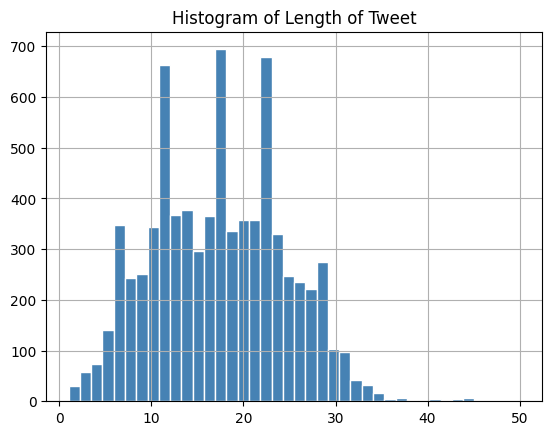

In [189]:
train['tweet_len'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Histogram of Length of Tweet')
plt.show()

In [190]:
from collections import Counter
def tokenise(text):
    return re.findall(r'\b[a-z]+\b', str(text).lower())

all_words = [w for text in train['text'] for w in tokenise(text)]
print(f"\nVocab size (Context): {len(set(all_words))}")
print("Top 20 words:", Counter(all_words).most_common(20))


Vocab size (Context): 15376
Top 20 words: [('the', 3291), ('a', 2204), ('in', 1991), ('to', 1956), ('of', 1834), ('i', 1773), ('and', 1429), ('is', 1366), ('you', 909), ('for', 898), ('on', 865), ('it', 774), ('my', 694), ('not', 658), ('that', 620), ('with', 609), ('are', 546), ('at', 542), ('by', 527), ('s', 509)]


target
0    57.034021
1    42.965979
Name: proportion, dtype: float64


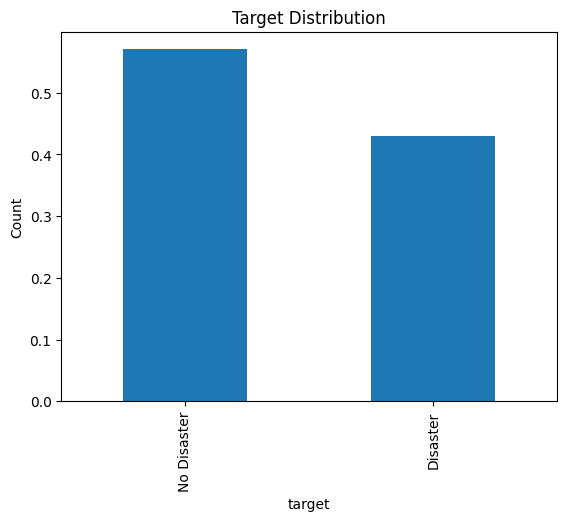

In [191]:
sent_counts = train["target"].value_counts(normalize=True)
print(sent_counts*100)

sent_counts.plot(kind="bar")
plt.title("Target Distribution")
plt.xticks([0,1], ['No Disaster', 'Disaster'])
plt.ylabel("Count")
plt.show()


Cleaning Text

In [192]:
from nltk.tokenize import word_tokenize
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [193]:
CONTRACTION_MAP = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
    "'cause": "because", "could've": "could have", "couldn't": "could not",
    "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hasn't": "has not", "haven't": "have not", "he'd": "he would", "he'll": "he will",
    "he's": "he is", "how'd": "how did", "how'll": "how will", "how's": "how is",
    "i'd": "i would", "i'd've": "i would have", "i'll": "i will", "i'll've": "i will have",
    "i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
    "it'll": "it will", "it's": "it is", "let's": "let us", "ma'am": "madam",
    "mightn't": "might not", "must've": "must have", "n't": " not", "needn't": "need not",
    "she'd": "she would", "she'll": "she will", "she's": "she is", "should've": "should have",
    "shouldn't": "should not", "that'd": "that would", "that's": "that is",
    "there'd": "there would", "there's": "there is", "they'd": "they would",
    "they'll": "they will", "they're": "they are", "they've": "they have",
    "we'd": "we would", "we're": "we are", "we've": "we have", "weren't": "were not",
    "what'll": "what will", "what're": "what are", "what's": "what is",
    "where's": "where is", "who'd": "who would", "who'll": "who will", "who's": "who is",
    "won't": "will not", "wouldn't": "would not", "you'd": "you would", "you'll": "you will",
    "you're": "you are"
}


def clean_text(text):
    # Convert to string
    text = str(text)
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove hyperlinks
    text = re.sub(r'http\S+|https\S+|www\.\S+|bit\.ly\S*', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'&[a-z]+;', '', text) 
    # Remove hashtags
    text = re.sub(r'#', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '<MENTION>', text) 
    # remove special characters
    text = re.sub(r'\\x[0-9A-Fa-f]{2}|[^a-zA-Z0-9\s.,?!<>()\'\"]', ' ', text)
    # removes multiple occurrences (eg: nooooooo -> noo)
    text = re.sub(r'([a-z])\1{2,}', r'\1\1', text) 
    # remove meaningless characters
    text = re.sub(r'\\x[0-9A-Fa-f]{2}|[^a-zA-Z0-9\s.,?!<>()\'\"]', ' ', text)
    # Numbers 
    text = re.sub(r'\d+', '', text)
    # Excess whitespace left behind by all the removals above
    text = re.sub(r'\s+', ' ', text).strip()

    # contraction expansion 
    words = text.split()
    expanded_words = []
    for word in words:
        if word in CONTRACTION_MAP:
            expanded_words.extend(CONTRACTION_MAP[word].split())
        else:
            expanded_words.append(word)
    text = ' '.join(expanded_words)
    
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # Lemmatize tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into a string
    return ' '.join(tokens) 

In [194]:
clean_text("OMG! Tsunami is coming! Check out this link: http://bit.ly/1234. @john_doe you'll never believe this!!! Noooooooo. I'm afraid &amp; I can't do anything.")

'omg tsunami coming check link johndoe youll never believe noo im afraid amp cant anything'

In [195]:
train["clean_text"] = train["text"].apply(clean_text)

In [196]:
train[['text', 'clean_text']].head(2)

,text,clean_text
0,Our Deeds are the Reason of this # earthquake...,deed reason earthquake may allah forgive u
1,Forest fire near La Ronge Sask . Canada,forest fire near la ronge sask canada


In [197]:
train[['text', 'clean_text']].tail(2)

,text,clean_text
7611,Police investigating after an e - bike collide...,police investigating e bike collided car littl...
7612,The Latest : More Homes Razed by Northern Cal...,latest home razed northern california wildfire...


GloVe Word Embeddings

In [24]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [198]:
X_train, X_test, y_train, y_test = train_test_split(
    train['clean_text'], train['target'], test_size=0.2, random_state=0, stratify=train['target']
)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

In [199]:
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)          # TRAIN ONLY

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=50, padding='pre')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=50, padding='pre')

In [200]:
len(tokenizer.word_index) # Dictionary Size

12917

In [28]:
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-100")

In [201]:
EMBED_DIM  = 100
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in glove:                        
        embedding_matrix[idx] = glove[word]

print(f"Non-zero rows: {(~(embedding_matrix == 0).all(axis=1)).sum()}")
print(f"Matrix shape: {embedding_matrix.shape}")

embedding_matrix = embedding_matrix.astype('float32')

Non-zero rows: 9738
Matrix shape: (12918, 100)


In [202]:
print(embedding_matrix.shape)
print(len(glove))
glove['happy']

(12918, 100)
400000


array([-0.090436 ,  0.19636  ,  0.29474  , -0.47706  , -0.80436  ,
        0.3078   , -0.55205  ,  0.58453  , -0.17056  , -0.84846  ,
        0.19528  ,  0.23671  ,  0.46827  , -0.58977  , -0.12163  ,
       -0.24697  , -0.072944 ,  0.17259  , -0.0485   ,  0.9527   ,
        0.50629  ,  0.58497  , -0.19367  , -0.45459  , -0.031095 ,
        0.51633  , -0.24052  , -0.1007   ,  0.53627  ,  0.024225 ,
       -0.50162  ,  0.73692  ,  0.49468  , -0.34744  ,  0.89337  ,
        0.057439 , -0.19127  ,  0.39333  ,  0.21182  , -0.89837  ,
        0.078704 , -0.16344  ,  0.45261  , -0.41096  , -0.19499  ,
       -0.13489  , -0.016313 , -0.021849 ,  0.17136  , -1.2413   ,
        0.079503 , -0.91144  ,  0.35699  ,  0.36289  , -0.24934  ,
       -2.1196   ,  0.14534  ,  0.52964  ,  0.90134  ,  0.033603 ,
        0.022809 ,  0.70625  , -1.0362   , -0.59809  ,  0.70592  ,
       -0.072793 ,  0.67033  ,  0.52763  , -0.47807  , -0.67374  ,
        0.36632  , -0.38284  , -0.10349  , -0.6402   ,  0.1810

TF-IDF Embeddings

In [45]:
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(train['clean_text'], train['target'], test_size = 0.2, stratify=train['target'], random_state=0)

In [46]:
tfidf = TfidfVectorizer(min_df=1, ngram_range=(1, 2))
X_traint = tfidf.fit_transform(X_train_tf)
X_testt  = tfidf.transform(X_test_tf)

Establishing a baseline: RandomForest (compare performance of TF-IDF vs GloVe embeddings)

In [47]:
model_rf = RandomForestClassifier(class_weight='balanced', n_estimators = 1000)
model_rf.fit(X_traint,y_train_tf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [48]:
Pred_y_tf_r = model_rf.predict(X_testt)
y_pred_proba_tf_r = model_rf.predict_proba(X_testt)

In [49]:
print(classification_report(y_test, Pred_y_tf_r, target_names=['No Disaster','Disaster']))

              precision    recall  f1-score   support

 No Disaster       0.79      0.90      0.84       869
    Disaster       0.84      0.68      0.75       654

    accuracy                           0.81      1523
   macro avg       0.81      0.79      0.80      1523
weighted avg       0.81      0.81      0.80      1523



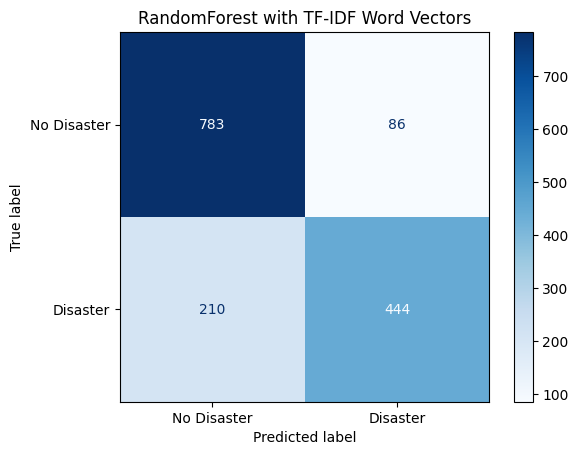

In [50]:
cm_tf_r = confusion_matrix(y_test, Pred_y_tf_r)
ConfusionMatrixDisplay(cm_tf_r, display_labels=['No Disaster', 'Disaster']).plot(cmap='Blues')
plt.title('RandomForest with TF-IDF Word Vectors')
plt.show()

In [51]:
def average_glove(texts, glove_model, dim=100):
    vectors = []
    for text in texts:
        words = text.split()
        word_vecs = [glove_model[w] for w in words if w in glove_model]
        if word_vecs:
            vectors.append(np.mean(word_vecs, axis=0))
        else:
            vectors.append(np.zeros(dim))
    return np.array(vectors)

X_train_glove = average_glove(X_train_tf, glove)
X_test_glove  = average_glove(X_test_tf,  glove)

model_rf.fit(X_train_glove,y_train_tf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [52]:
Pred_y_glove_r = model_rf.predict(X_test_glove)
y_pred_proba_glove_r = model_rf.predict_proba(X_test_glove)

In [53]:
print(classification_report(y_test, Pred_y_glove_r, target_names=['No Disaster','Disaster']))

              precision    recall  f1-score   support

 No Disaster       0.79      0.90      0.84       869
    Disaster       0.83      0.68      0.75       654

    accuracy                           0.80      1523
   macro avg       0.81      0.79      0.79      1523
weighted avg       0.81      0.80      0.80      1523



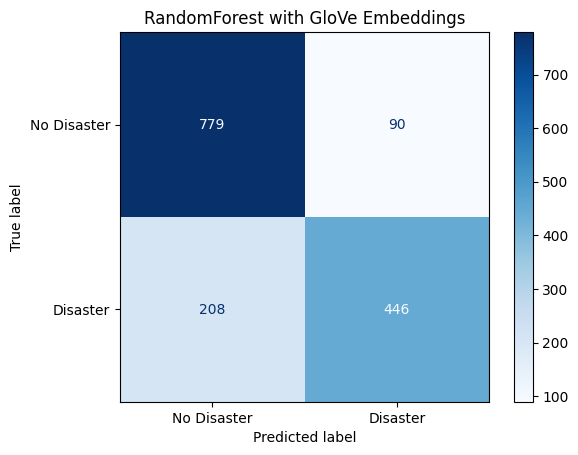

In [54]:
cm_glove_r = confusion_matrix(y_test, Pred_y_glove_r)
ConfusionMatrixDisplay(cm_glove_r, display_labels=['No Disaster', 'Disaster']).plot(cmap='Blues')
plt.title('RandomForest with GloVe Embeddings')
plt.show()

LSTM with pre-trained GloVe embeddings

In [95]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Embedding, SpatialDropout1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [223]:
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(0.8767636049524906), 1: np.float64(1.1635460450897974)}


In [224]:
sequences = tokenizer.texts_to_sequences(train['text'])
print(np.percentile([len(s) for s in sequences], [50, 90, 95, 99]))

[15. 23. 26. 29.]


In [225]:
def build_lstm(vocab_size=12918, embedding_dim=64, max_len=50):
    model = Sequential([
        # maps token integers to dense vectors
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,weights=[embedding_matrix],input_length=50,trainable=True),
        SpatialDropout1D(0.2),
        
        # sequence modelling
        
        LSTM(64),
        Dropout(0.2),
        
        # classification head
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [226]:
model_lstm = build_lstm()
print(model_lstm.summary())


/usr/local/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ ?                      │     1,291,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_18            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,291,800 (4.93 MB)

 Trainable params: 1,291,800 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

None


In [227]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',            
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_seq, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
    class_weight = class_weights
)

Epoch 1/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5823 - loss: 0.6653 - val_accuracy: 0.7085 - val_loss: 0.6273
Epoch 2/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7268 - loss: 0.5722 - val_accuracy: 0.7685 - val_loss: 0.5145
Epoch 3/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7763 - loss: 0.4995 - val_accuracy: 0.7841 - val_loss: 0.4864
Epoch 4/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7837 - loss: 0.4805 - val_accuracy: 0.7923 - val_loss: 0.4810
Epoch 5/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7972 - loss: 0.4618 - val_accuracy: 0.7964 - val_loss: 0.4657
Epoch 6/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8073 - loss: 0.4466 - val_accuracy: 0.8013 - val_loss: 0.4635
Epoch 7/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8095 - loss: 0.4420 - val_accuracy: 0.8046 - val_loss: 0.4607
Epoch 8/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8186 - loss: 0.4268 - val_accu

In [228]:
Pred_y_lstm= model_lstm.predict(X_test_seq)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [229]:
pred_nn_lstm = (Pred_y_lstm > 0.5).astype(int).flatten()

print(classification_report(y_test, pred_nn_lstm,  zero_division=0, target_names=['No Disaster', 'Disaster']))

              precision    recall  f1-score   support

 No Disaster       0.82      0.87      0.85       869
    Disaster       0.81      0.75      0.78       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523



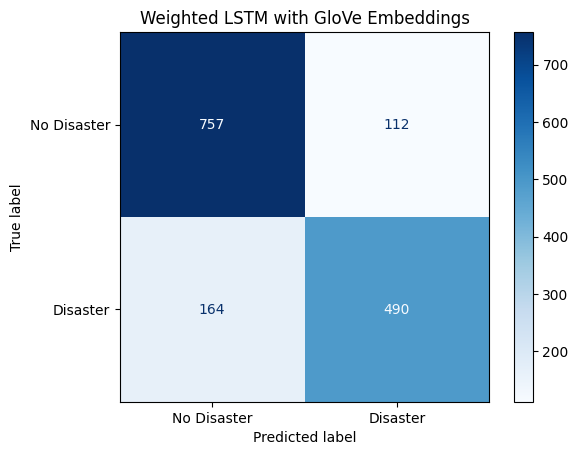

In [230]:
cmlstm = confusion_matrix(y_test, pred_nn_lstm)
ConfusionMatrixDisplay(cmlstm, display_labels=['No Disaster', 'Disaster']).plot(cmap='Blues')
plt.title('Weighted LSTM with GloVe Embeddings')
plt.show()


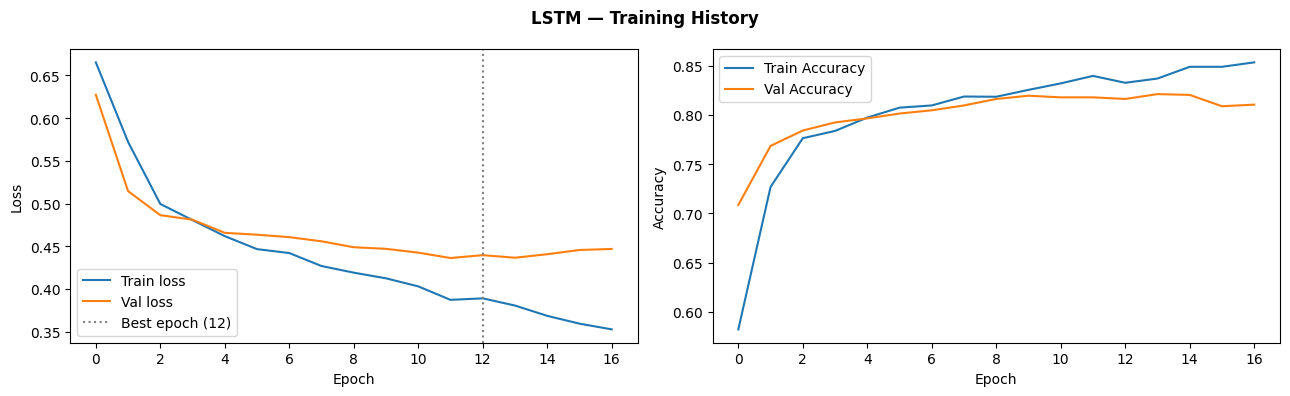

In [236]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_lstm.history['loss'],     label='Train loss')
axes[0].plot(history_lstm.history['val_loss'], label='Val loss')
best_epoch_lstm = np.argmin(history_lstm.history['val_loss']) + 1
axes[0].axvline(x=best_epoch_lstm, color='grey', linestyle=':', label=f'Best epoch ({best_epoch_lstm})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()


plt.suptitle('LSTM — Training History', fontweight='bold')
plt.tight_layout()

plt.show()

Fine-Tuning DistilBERT

In [237]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset

In [238]:
from huggingface_hub import login
login(token="hf_")

In [248]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',num_labels=2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [249]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, maxlen=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=maxlen,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

train_dataset = ReviewDataset(X_train, y_train, tokenizer)
test_dataset  = ReviewDataset(X_test,  y_test,  tokenizer)

In [253]:
from torch import nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        
        # compute weights from training labels
        weights = torch.tensor([
            len(y_train) / (2 * (y_train == 0).sum()),
            len(y_train) / (2 * (y_train == 1).sum()),
        ], dtype=torch.float).to(logits.device)
        
        loss_fn = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [254]:
training_args = TrainingArguments(
    output_dir='./results',          # output directory for model checkpoints
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=8,   # batch size per device during training
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [255]:
trainer_w = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer_w.train()

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,0.208354
20,0.247564
30,0.205635
40,0.391360
50,0.363653
60,0.222490
70,0.322389
80,0.516579
90,0.298757
100,0.328004


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2286, training_loss=0.22455492055846976, metrics={'train_runtime': 298.0845, 'train_samples_per_second': 61.291, 'train_steps_per_second': 7.669, 'total_flos': 193803426389160.0, 'train_loss': 0.22455492055846976, 'epoch': 3.0})

In [261]:
preds = trainer_w.predict(test_dataset)
y_pred_DBERT = np.argmax(preds.predictions, axis=1)

In [262]:

print(classification_report(y_test, y_pred_DBERT, zero_division=0,target_names=['No Disaster', 'Disaster']))

              precision    recall  f1-score   support

 No Disaster       0.83      0.83      0.83       869
    Disaster       0.77      0.77      0.77       654

    accuracy                           0.80      1523
   macro avg       0.80      0.80      0.80      1523
weighted avg       0.80      0.80      0.80      1523



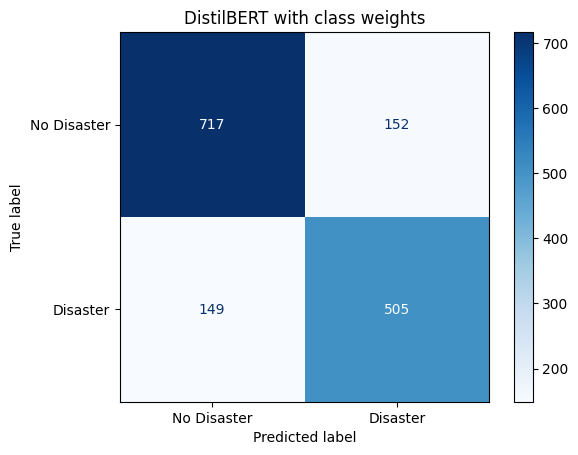

In [264]:
cmdbert = confusion_matrix(y_test, y_pred_DBERT)
ConfusionMatrixDisplay(cmdbert, display_labels=['No Disaster', 'Disaster']).plot(cmap='Blues')
plt.title('DistilBERT with class weights')
plt.show()

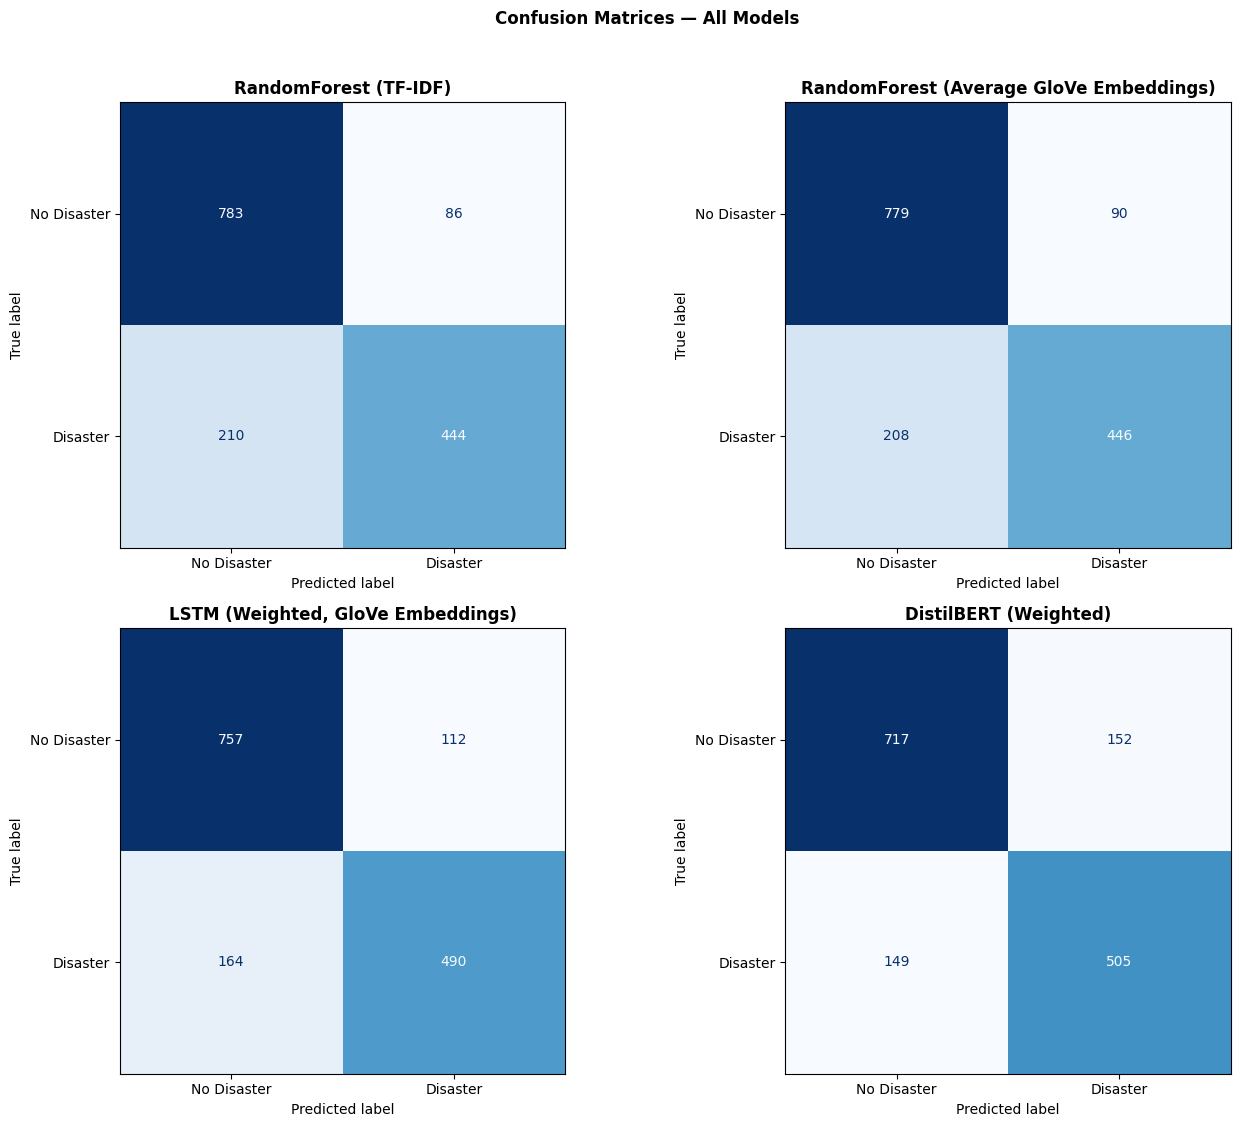

In [267]:
predictions = {
    'RandomForest (TF-IDF)':    Pred_y_tf_r,
    'RandomForest (Average GloVe Embeddings)':  Pred_y_glove_r,
    'LSTM (Weighted, GloVe Embeddings)':           pred_nn_lstm,
    'DistilBERT (Weighted)' : y_pred_DBERT,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Disaster', 'Disaster']).plot(
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()